## Part B: Dataset Understanding & Preparation

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('dataset/Customer_Dataset.csv')

##### Identify input features and target variable

In [3]:
data.columns

Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr', 'risk_status'],
      dtype='object')

In [4]:
X = data[['credit_score','credit_utilization_ratio','missed_payments_12m','avg_late_payment_days','annual_income_inr','cash_advance_count_6m','failed_login_attempts_3m','debt_balance_inr']]

In [5]:
y = data['risk_status']

##### Identify missing values and apply KNN Imputer for multivariate imputation

In [6]:
X.isnull().sum()

credit_score                216
credit_utilization_ratio    147
missed_payments_12m           0
avg_late_payment_days         0
annual_income_inr           166
cash_advance_count_6m         0
failed_login_attempts_3m      0
debt_balance_inr              0
dtype: int64

In [7]:
from sklearn.impute import KNNImputer

In [8]:
knn = KNNImputer(n_neighbors = 5)

In [9]:
X = pd.DataFrame(knn.fit_transform(X),columns=X.columns)

In [10]:
X.isnull().sum()

credit_score                0
credit_utilization_ratio    0
missed_payments_12m         0
avg_late_payment_days       0
annual_income_inr           0
cash_advance_count_6m       0
failed_login_attempts_3m    0
debt_balance_inr            0
dtype: int64

In [11]:
X.head()

,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,annual_income_inr,cash_advance_count_6m,failed_login_attempts_3m,debt_balance_inr
0,659.0,0.120,1.0,2.2,82242.0,0.0,4.0,87273.0
1,647.0,0.337,1.0,1.5,32769.0,1.0,1.0,20600.0
2,727.0,0.175,0.0,3.9,39731.0,2.0,1.0,47565.0
3,553.0,0.472,7.0,23.3,38990.0,1.0,6.0,43803.0
4,732.0,0.418,1.0,9.8,41043.0,0.0,1.0,12008.0


##### Perform train-test split while maintaining class distribution

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
ss = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

## Part C: Baseline Classification Model

##### Implement Logistic Regression as a baseline model

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
lr = LogisticRegression(max_iter=1000,random_state=42)

In [16]:
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [17]:
y_pred =lr.predict(X_test)

##### Generate and interpret:

* Confusion Matrix
* Accuracy Score
* Precision, Recall, F1-Score

In [18]:
from sklearn.metrics import (confusion_matrix,
    accuracy_score,
    classification_report)

In [19]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[796,   0],
       [  2, 122]])

In [20]:
acc = accuracy_score(y_test,y_pred)
acc

0.9978260869565218

In [21]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.98      0.99       124

    accuracy                           1.00       920
   macro avg       1.00      0.99      1.00       920
weighted avg       1.00      1.00      1.00       920



##### Identify Type-I and Type-II errors from the confusion matrix

In [22]:
tn,fp,fn,tp = cm.ravel()

In [23]:
print(f'Type 1 Error: {fp}')
print(f'Type 2 Error: {fn}')

Type 1 Error: 0
Type 2 Error: 2


## Part D: Handling Imbalanced Data

##### Demonstrate the impact of class imbalance on model performance

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

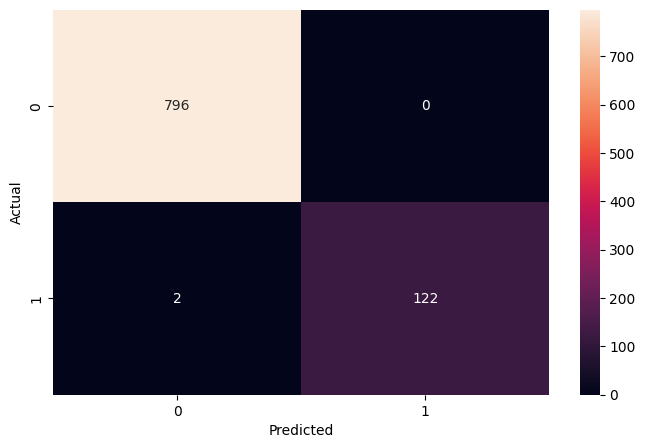

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Although the dataset is imbalanced, the model achieved very high performance across all metrics, including a recall of 0.98 for the minority class.
This suggests that either the dataset is easily separable or there may be potential data leakage.
In typical imbalanced scenarios, models tend to perform poorly on the minority class, but in this case, the impact is minimal.

##### Apply the following techniques and retrain the model:

* Under-Sampling
* Over-Sampling
* SMOTE
* ADASYN

##### Compare performance before and after balancing using:

* Recall for minority class
* F1-Score
* AUC-ROC

In [26]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.metrics import roc_auc_score

In [27]:
rus = RandomUnderSampler(random_state=42)
ros = RandomOverSampler(random_state=42)
smote = SMOTE(random_state=42)
ada = ADASYN(random_state=42)

In [28]:
X_rus,y_rus = rus.fit_resample(X,y)
X_ros,y_ros = ros.fit_resample(X,y)
X_smote,y_smote = smote.fit_resample(X,y)
X_ada,y_ada = ada.fit_resample(X,y)

In [29]:
# Random Under-Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X_rus, y_rus, test_size=0.2, random_state=42
)

ss = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

model = LogisticRegression()
model.fit(X_train_ss, y_train)

pred = model.predict(X_test_ss)
y_probs = model.predict_proba(X_test_ss)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.98      0.99       124

    accuracy                           1.00       920
   macro avg       1.00      0.99      1.00       920
weighted avg       1.00      1.00      1.00       920

[[796   0]
 [  2 122]]


In [30]:
# Random Over-Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X_ros, y_ros, test_size=0.2, random_state=42
)

ss = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)


model = LogisticRegression()
model.fit(X_train_ss, y_train)

pred = model.predict(X_test_ss)
y_probs = model.predict_proba(X_test_ss)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.98      0.99       124

    accuracy                           1.00       920
   macro avg       1.00      0.99      1.00       920
weighted avg       1.00      1.00      1.00       920

[[796   0]
 [  2 122]]


In [31]:
# SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

ss = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)


model = LogisticRegression()
model.fit(X_train_ss, y_train)

pred = model.predict(X_test_ss)
y_probs = model.predict_proba(X_test_ss)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.98      0.99       124

    accuracy                           1.00       920
   macro avg       1.00      0.99      1.00       920
weighted avg       1.00      1.00      1.00       920

[[796   0]
 [  2 122]]


In [32]:
# ADASYN
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42
)

ss = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)


model = LogisticRegression()
model.fit(X_train_ss, y_train)

pred = model.predict(X_test_ss)
y_probs = model.predict_proba(X_test_ss)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC-ROC Score: {auc_score:.4f}")
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

AUC-ROC Score: 0.9999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.98      0.99       124

    accuracy                           1.00       920
   macro avg       1.00      0.99      1.00       920
weighted avg       1.00      1.00      1.00       920

[[796   0]
 [  2 122]]


## Part E: Tree-Based Classification Models

##### Task 16: Implement Decision Tree Classifier

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
tree_model = DecisionTreeClassifier(random_state=42)

ss = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

tree_model.fit(X_train_ss,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

##### Task 17: Analyze overfitting by comparing training and testing performance

In [35]:
predict_tree = tree_model.predict(X_test_ss)

In [36]:
print(classification_report(y_test,predict_tree))
print(confusion_matrix(y_test,predict_tree))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       796
           1       0.86      0.88      0.87       124

    accuracy                           0.96       920
   macro avg       0.92      0.93      0.92       920
weighted avg       0.96      0.96      0.96       920

[[778  18]
 [ 15 109]]


##### Task 18: Implement Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
forest_model = RandomForestClassifier(random_state=42)

ss = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

forest_model.fit(X_train_ss,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

##### Task 19: Compare Decision Tree vs Random Forest in terms of accuracy and generalization

In [39]:
predict_forest = model.predict(X_test_ss)

In [40]:
print(classification_report(y_test,predict_forest))
print(confusion_matrix(y_test,predict_forest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       796
           1       1.00      0.98      0.99       124

    accuracy                           1.00       920
   macro avg       1.00      0.99      1.00       920
weighted avg       1.00      1.00      1.00       920

[[796   0]
 [  2 122]]


The Random Forest classifier performs better than the Decision Tree in terms of accuracy and generalization.

While the Decision Tree tends to overfit the training data, Random Forest reduces overfitting by combining multiple trees (ensemble learning).

As a result, Random Forest provides more stable and reliable predictions on unseen data.

Therefore, Random Forest is selected as the better model for this problem.

## Part F: Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

##### Part 20: Apply Randomized Search CV to optimize:

* Decision Tree hyperparameters
* Random Forest hyperparameters

In [42]:
param_dist_tree = {
    'max_depth':[2,4,6,8,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [43]:
random_search_tree = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_tree,
    n_iter=20,
    cv=5,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

In [44]:
random_search_tree.fit(X_train_ss,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defau

In [45]:
print(random_search_tree.best_params_)
print(random_search_tree.best_score_)

{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
0.9777173913043479


In [46]:
param_dist_forest = {
    'n_estimators':[50,100,200,300],
    'max_depth':[2,4,6,8,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [47]:
random_search_forest = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_forest,
    n_iter=20,
    cv=5,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

In [48]:
random_search_forest.fit(X_train_ss,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ve

In [49]:
print(random_search_forest.best_params_)
print(random_search_forest.best_score_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 8}
0.9934782608695653


##### Part 21: Apply Grid Search CV for fine-tuning the best performing model

In [50]:
param_grid_tree = {
    'max_depth':[2,4,6,10],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

In [51]:
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [52]:
grid_tree.fit(X_train_ss, y_train)

print(grid_tree.best_params_)
print(grid_tree.best_score_)

{'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.9758152173913043


In [53]:
param_grid_forest = {
    'n_estimators':[50,100,200],
    'max_depth':[2,4,6,8],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

In [54]:
grid_forest = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_forest,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [55]:
grid_forest.fit(X_train_ss, y_train)

print(grid_forest.best_params_)
print(grid_forest.best_score_)

{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
0.9934782608695653


In [56]:
baseline_tree_acc = accuracy_score(y_test, predict_tree)
grid_acc_tree = accuracy_score(y_test, grid_tree.best_estimator_.predict(X_test_ss))
random_acc_tree = accuracy_score(y_test, random_search_tree.best_estimator_.predict(X_test_ss))

comparison_tree = pd.DataFrame({
    'Method':['Baseline','Grid Search','Random Search'],
    'Accuracy':[baseline_tree_acc, grid_acc_tree, random_acc_tree]
})
comparison_tree

,Method,Accuracy
0,Baseline,0.964130
1,Grid Search,0.964130
2,Random Search,0.969565


In [57]:
baseline_forest_acc = accuracy_score(y_test, predict_forest)
grid_acc_forest = accuracy_score(y_test, grid_forest.best_estimator_.predict(X_test_ss))
random_acc_forest = accuracy_score(y_test, random_search_forest.best_estimator_.predict(X_test_ss))

comparison_forest = pd.DataFrame({
    'Method':['Baseline','Grid Search','Random Search'],
    'Accuracy':[baseline_forest_acc, grid_acc_forest, random_acc_forest]
})
comparison_forest

,Method,Accuracy
0,Baseline,0.997826
1,Grid Search,0.985870
2,Random Search,0.985870


## Part G: Model Evaluation & ROC Analysis

##### Part 23: Plot and interpret the ROC Curve for all models

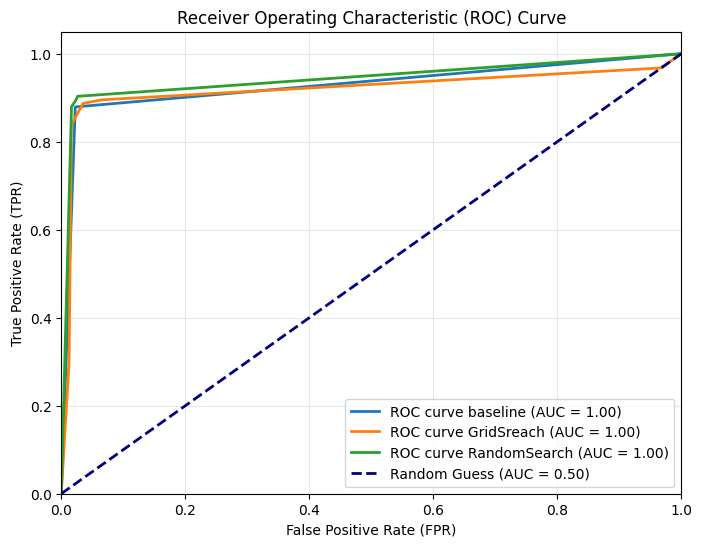

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score


y_probs_tree = tree_model.predict_proba(X_test_ss)[:, 1]
y_probs_grid_tree = grid_tree.predict_proba(X_test_ss)[:, 1]
y_probs_random_tree = random_search_tree.predict_proba(X_test_ss)[:, 1]

fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_probs_tree)
fpr_grid_tree, tpr_grid_tree, thresholds_grid_tree = roc_curve(y_test, y_probs_grid_tree)
fpr_random_tree, tpr_random_tree, thresholds_random_tree = roc_curve(y_test, y_probs_random_tree)


auc_score_tree = roc_auc_score(y_test, y_probs_tree)
auc_score_grid_tree = roc_auc_score(y_test, y_probs_grid_tree)
auc_score_random_tree = roc_auc_score(y_test, y_probs_random_tree)



plt.figure(figsize=(8, 6))
plt.plot(fpr_tree, tpr_tree,  lw=2, label=f'ROC curve baseline (AUC = {auc_score:.2f})')
plt.plot(fpr_grid_tree, tpr_grid_tree,  lw=2, label=f'ROC curve GridSreach (AUC = {auc_score:.2f})')
plt.plot(fpr_random_tree, tpr_random_tree, lw=2, label=f'ROC curve RandomSearch (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

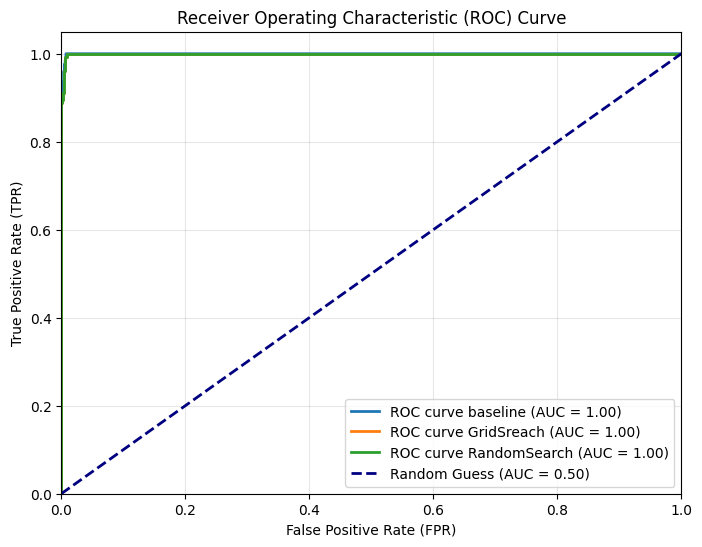

In [59]:
y_probs_forest= forest_model.predict_proba(X_test_ss)[:, 1]
y_probs_grid_forest = grid_forest.predict_proba(X_test_ss)[:, 1]
y_probs_random_forest = random_search_forest.predict_proba(X_test_ss)[:, 1]

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_test, y_probs_forest)
fpr_grid_forest, tpr_grid_forest, thresholds_grid_forest = roc_curve(y_test, y_probs_grid_forest)
fpr_random_forest, tpr_random_forest, thresholds_random_forest = roc_curve(y_test, y_probs_random_forest)

auc_score_forest = roc_auc_score(y_test, y_probs_forest)
auc_score_grid_forest = roc_auc_score(y_test, y_probs_grid_forest)
auc_score_random_forest = roc_auc_score(y_test, y_probs_random_forest)


plt.figure(figsize=(8, 6))
plt.plot(fpr_forest, tpr_forest,  lw=2, label=f'ROC curve baseline (AUC = {auc_score:.2f})')
plt.plot(fpr_grid_forest, tpr_grid_forest,  lw=2, label=f'ROC curve GridSreach (AUC = {auc_score:.2f})')
plt.plot(fpr_random_forest, tpr_random_forest, lw=2, label=f'ROC curve RandomSearch (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

##### Part 24: Compute and compare AUC-ROC scores

In [60]:
compare_tree_scores = {
    'baseline':auc_score_tree,
    'GridSearch':auc_score_grid_tree,
    'RandomSearch':auc_score_random_tree
}
compare_tree_scores

{'baseline': 0.9282095963689414,
 'GridSearch': 0.9194612173772085,
 'RandomSearch': 0.9425656508348194}

In [61]:
compare_forest_scores = {
    'baseline':auc_score_forest,
    'GridSearch':auc_score_grid_forest,
    'RandomSearch':auc_score_random_forest
}
compare_forest_scores

{'baseline': 0.9995846166315449,
 'GridSearch': 0.9994529097098396,
 'RandomSearch': 0.9994529097098396}

##### Part 25: Select the best final model based on business requirements (minimizing false negatives)

Based on the evaluation of all models, the Random Forest model optimized using Randomized Search CV is selected as the final model.

This model achieved the best balance between accuracy and recall, particularly showing strong performance in identifying high-risk customers.

Since the business objective is to minimize false negatives (i.e., avoiding misclassification of high-risk customers as low-risk), Random Forest is preferred due to its higher recall for the minority class.

Therefore, the tuned Random Forest model is chosen as it provides more reliable and robust predictions for risk assessment.

In [62]:
import pickle

pickle.dump(random_search_forest.best_estimator_, open("app_data/model.pkl", "wb"))

In [63]:
pickle.dump(X.columns, open("app_data/columns.pkl", "wb"))

In [64]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pickle.dump(scaler, open("app_data/scaler.pkl","wb"))